In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('pitching.csv', sep=';', decimal=',')
df.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches,player_name_eng
0,ST,2018-09-02,80.0,-2.14,5.96,"Ohtani, Shohei",514888,660271,field_out,hit_into_play,...,3.24,-1.18,-1.18,NaN,NaN,NaN,NaN,NaN,NaN,Shohei Ohtani
1,FF,2018-09-02,92.7,-2.08,6.06,"Ohtani, Shohei",514888,660271,NaN,foul,...,1.33,0.27,0.27,NaN,NaN,NaN,NaN,NaN,NaN,Shohei Ohtani
2,FF,2018-09-02,92.5,-2.03,6.10,"Ohtani, Shohei",514888,660271,NaN,called_strike,...,1.33,0.17,0.17,NaN,NaN,NaN,NaN,NaN,NaN,Shohei Ohtani
3,FF,2018-09-02,91.6,-2.02,6.13,"Ohtani, Shohei",514888,660271,NaN,ball,...,1.39,0.26,0.26,NaN,NaN,NaN,NaN,NaN,NaN,Shohei Ohtani
4,ST,2018-09-02,77.0,-2.28,5.87,"Ohtani, Shohei",543807,660271,home_run,hit_into_play,...,3.73,-1.43,-1.43,NaN,NaN,NaN,NaN,NaN,NaN,Shohei Ohtani


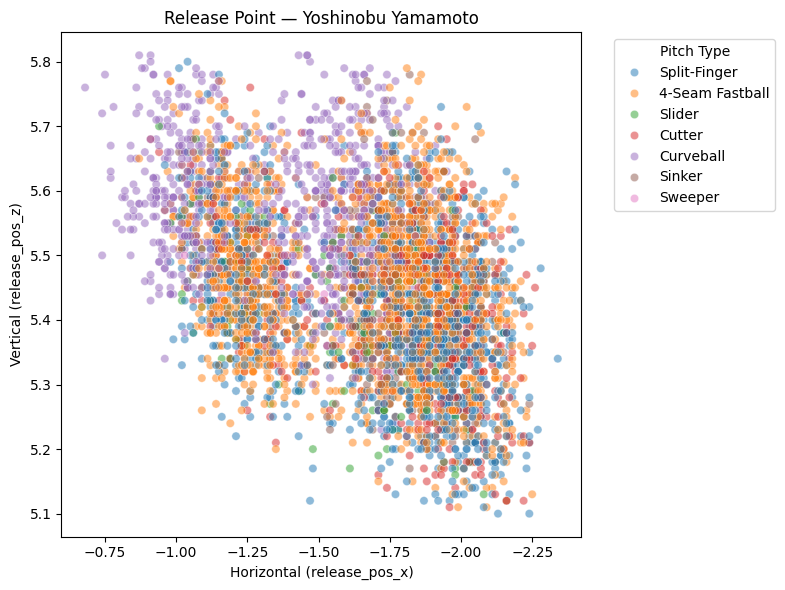

In [3]:
# RELEASE POINT DE PITCHERS DA SUA ESCOLHA, E PODE FILTRAR POR ARREMESSO TAMBÉM. NESSE HÁ UM FILTRO PARA LIMPAR OS OUTLIERS, QUE SÃO ERROS DO BANCO DE DADOS ORIGINAL

PITCHER = "Yoshinobu Yamamoto"
PITCHES = []  # [] = todos os pitches

pitcher_df = df[df['player_name_eng'] == PITCHER].copy()

if PITCHES:
    pitcher_df = pitcher_df[pitcher_df['pitch_name'].isin(PITCHES)]

# filtro de outliers com IQR
def remove_outliers_iqr(df, col, multiplier=1.4): # o multiplier é onde vc ajeita esse filtro de outliers, quanto menor o número, maior o filtro.
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - multiplier * IQR) & (df[col] <= Q3 + multiplier * IQR)]

pitcher_df = remove_outliers_iqr(pitcher_df, 'release_pos_x')
pitcher_df = remove_outliers_iqr(pitcher_df, 'release_pos_z')
# ----------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=pitcher_df,
    x='release_pos_x',
    y='release_pos_z',
    hue='pitch_name',
    alpha=0.5,
    ax=ax
)

ax.set_title(f'Release Point — {PITCHER}')
ax.set_xlabel('Horizontal (release_pos_x)')
ax.set_ylabel('Vertical (release_pos_z)')
ax.invert_xaxis()
plt.legend(title='Pitch Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

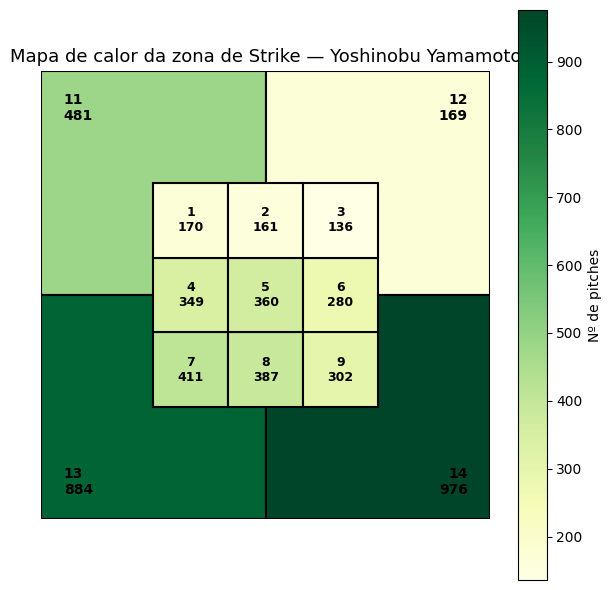

In [4]:
# GERAR MAPA DE CALOR DA STRIKEZONE DE UM PITCHER.

PITCHER = "Yoshinobu Yamamoto"
PITCHES = []

pitcher_df = df[df['player_name_eng'] == PITCHER].copy()

if PITCHES:
    pitcher_df = pitcher_df[pitcher_df['pitch_name'].isin(PITCHES)]

zone_counts = pitcher_df['zone'].value_counts().to_dict()

all_values = list(zone_counts.values())
vmin, vmax = min(all_values), max(all_values)
cmap = plt.cm.YlGn

def get_color(zone):
    val = zone_counts.get(zone, 0)
    return cmap((val - vmin) / (vmax - vmin))

fig, ax = plt.subplots(figsize=(6, 6))

outer = {'x': 0, 'y': 0, 'size': 3}
inner = {'x': 0.75, 'y': 0.75, 'size': 1.5}
cell = inner['size'] / 3
mid_y = outer['size'] / 2  # divisão lateral bem no meio = 1.5

# zonas externas cobrindo toda a lateral, divididas no meio vertical
# posição do texto por zona (canto mais longe da grade interna)
ext_zones = [
    (11, 0,                mid_y, outer['size']/2, outer['size'] - mid_y),
    (12, outer['size']/2,  mid_y, outer['size']/2, outer['size'] - mid_y),
    (13, 0,                0,     outer['size']/2, mid_y),
    (14, outer['size']/2,  0,     outer['size']/2, mid_y),
]

text_positions = {
    11: (0.15, 2.85, 'left',   'top'),     # canto top-left
    12: (2.85, 2.85, 'right',  'top'),     # canto top-right
    13: (0.15, 0.15, 'left',   'bottom'),  # canto bot-left
    14: (2.85, 0.15, 'right',  'bottom'),  # canto bot-right
}

for zone, x, y, w, h in ext_zones:
    color = get_color(zone)
    ax.add_patch(plt.Rectangle((x, y), w, h, color=color, ec='black', lw=1.5))
    tx, ty, ha, va = text_positions[zone]
    ax.text(tx, ty, f'{zone}\n{zone_counts.get(zone, 0)}',
            ha=ha, va=va, fontsize=10, fontweight='bold', color='black')

# zonas internas (grade 3x3) por cima
inner_zones = [
    [7, 8, 9],
    [4, 5, 6],
    [1, 2, 3],
]

for row_idx, row in enumerate(inner_zones):
    for col_idx, zone in enumerate(row):
        x = inner['x'] + col_idx * cell
        y = inner['y'] + row_idx * cell
        color = get_color(zone)
        ax.add_patch(plt.Rectangle((x, y), cell, cell, color=color, ec='black', lw=1.5))
        ax.text(x + cell/2, y + cell/2, f'{zone}\n{zone_counts.get(zone, 0)}',
                ha='center', va='center', fontsize=9, fontweight='bold', color='black')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Nº de pitches')

ax.set_xlim(0, 3)
ax.set_ylim(0, 3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'Mapa de calor da zona de Strike — {PITCHER}', fontsize=13)
plt.tight_layout()
plt.show()

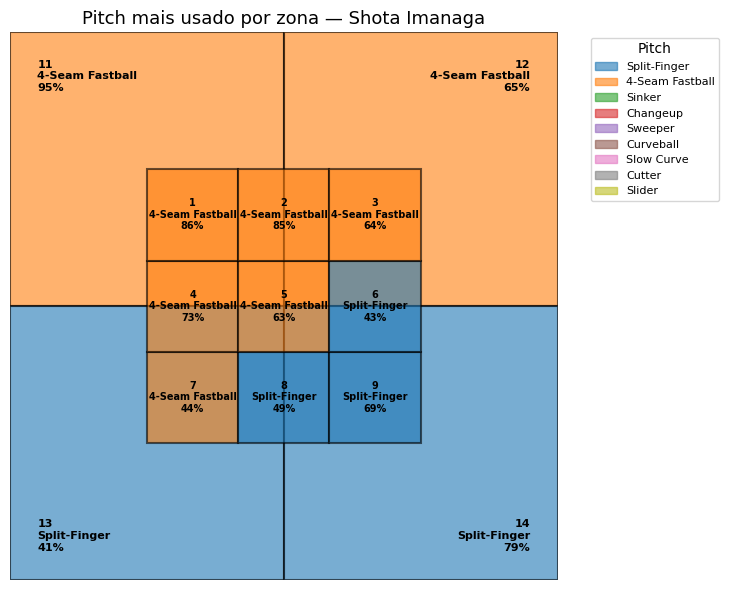

In [6]:
# GERAR MAPA DE CALOR QUE MOSTRA O PITCH MAIS USADO EM CADA PARTE DA ZONA.

PITCHER = "Shota Imanaga"

pitcher_df = df[df['player_name_eng'] == PITCHER].copy()

# pitch mais usado por zona
dominant = (
    pitcher_df.groupby(['zone', 'pitch_name'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .groupby('zone')
    .first()
    .reset_index()
)
dominant_map = dict(zip(dominant['zone'], dominant['pitch_name']))
count_map = dict(zip(dominant['zone'], dominant['count']))

# total por zona pra calcular %
total_map = pitcher_df['zone'].value_counts().to_dict()

# paleta de cores por pitch
pitches = pitcher_df['pitch_name'].dropna().unique()
palette = sns.color_palette('tab10', len(pitches))
pitch_color = dict(zip(pitches, palette))

fig, ax = plt.subplots(figsize=(7, 6))

outer = {'x': 0, 'y': 0, 'size': 3}
inner = {'x': 0.75, 'y': 0.75, 'size': 1.5}
cell = inner['size'] / 3
mid_y = outer['size'] / 2

ext_zones = [
    (11, 0,                outer['size']/2, outer['size']/2, outer['size'] - outer['size']/2),
    (12, outer['size']/2,  outer['size']/2, outer['size']/2, outer['size'] - outer['size']/2),
    (13, 0,                0,               outer['size']/2, outer['size']/2),
    (14, outer['size']/2,  0,               outer['size']/2, outer['size']/2),
]

text_positions = {
    11: (0.15, 2.85, 'left',  'top'),
    12: (2.85, 2.85, 'right', 'top'),
    13: (0.15, 0.15, 'left',  'bottom'),
    14: (2.85, 0.15, 'right', 'bottom'),
}

def zone_text(zone, x, y, w, h, fontsize=9):
    pitch = dominant_map.get(zone, 'N/A')
    total = total_map.get(zone, 0)
    pct = round(count_map.get(zone, 0) / total * 100) if total > 0 else 0
    color = pitch_color.get(pitch, (0.8, 0.8, 0.8))
    ax.add_patch(plt.Rectangle((x, y), w, h, color=color, alpha=0.6, ec='black', lw=1.5))
    return pitch, total, pct

for zone, x, y, w, h in ext_zones:
    pitch, total, pct = zone_text(zone, x, y, w, h, fontsize=8)
    tx, ty, ha, va = text_positions[zone]
    ax.text(tx, ty, f'{zone}\n{pitch}\n{pct}%',
            ha=ha, va=va, fontsize=8, fontweight='bold', color='black')

inner_zones = [[7,8,9],[4,5,6],[1,2,3]]

for row_idx, row in enumerate(inner_zones):
    for col_idx, zone in enumerate(row):
        x = inner['x'] + col_idx * cell
        y = inner['y'] + row_idx * cell
        pitch, total, pct = zone_text(zone, x, y, cell, cell)
        ax.text(x + cell/2, y + cell/2,
                f'{zone}\n{pitch}\n{pct}%',
                ha='center', va='center', fontsize=7, fontweight='bold', color='black')

# legenda dos pitches
handles = [plt.Rectangle((0,0),1,1, color=pitch_color[p], alpha=0.6) for p in pitches]
ax.legend(handles, pitches, title='Pitch', bbox_to_anchor=(1.05, 1),
          loc='upper left', fontsize=8)

ax.set_xlim(0, 3)
ax.set_ylim(0, 3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'Pitch mais usado por zona — {PITCHER}', fontsize=13)
plt.tight_layout()
plt.show()

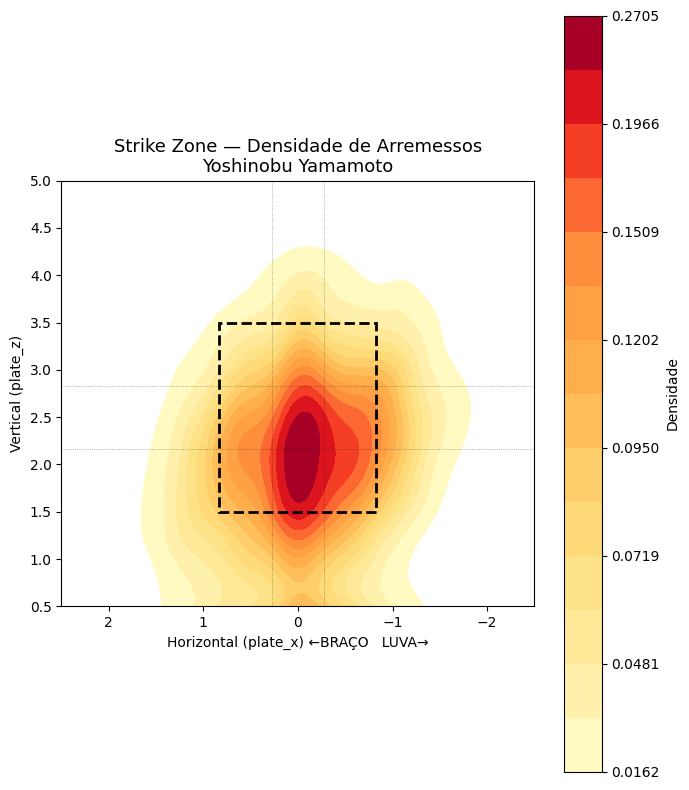

In [7]:
# STRIKE ZONE COM DENSIDADE (KDE)

PITCHER = "Yoshinobu Yamamoto"
PITCHES = []

pitcher_df = df[df['player_name_eng'] == PITCHER].copy()

if PITCHES:
    pitcher_df = pitcher_df[pitcher_df['pitch_name'].isin(PITCHES)]

# remove outliers
def remove_outliers_iqr(df, col, multiplier=1.5):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - multiplier * IQR) & (df[col] <= Q3 + multiplier * IQR)]

pitcher_df = remove_outliers_iqr(pitcher_df, 'plate_x')
pitcher_df = remove_outliers_iqr(pitcher_df, 'plate_z')

fig, ax = plt.subplots(figsize=(7, 8))

# KDE por pitch ou geral
if len(pitcher_df['pitch_name'].unique()) > 1 and not PITCHES:
    # sem filtro: plota KDE geral
    sns.kdeplot(
        data=pitcher_df,
        x='plate_x',
        y='plate_z',
        fill=True,
        cmap='YlOrRd',
        thresh=0.05,
        levels=15,
        ax=ax
    )
else:
    # com filtro: plota KDE por pitch com cores diferentes
    sns.kdeplot(
        data=pitcher_df,
        x='plate_x',
        y='plate_z',
        hue='pitch_name',
        fill=True,
        thresh=0.05,
        levels=10,
        alpha=0.5,
        ax=ax
    )

# desenha a strike zone (valores padrão do Statcast em pés)
strike_zone = plt.Rectangle(
    (-0.83, 1.5),   # x, y (canto inferior esquerdo)
    1.66,           # largura (17 polegadas)
    2.0,            # altura média (1.5 a 3.5)
    fill=False,
    edgecolor='black',
    linewidth=2,
    linestyle='--'
)
ax.add_patch(strike_zone)

# divide a strike zone em 9 zonas internas
for i in range(1, 3):
    ax.axvline(-0.83 + i * (1.66/3), ymin=0, ymax=1,
               color='black', lw=0.6, ls=':', alpha=0.4)
for i in range(1, 3):
    y = 1.5 + i * (2.0/3)
    ax.axhline(y, color='black', lw=0.6, ls=':', alpha=0.4)

ax.set_title(f'Strike Zone — Densidade de Arremessos\n{PITCHER}', fontsize=13)
ax.set_xlabel('Horizontal (plate_x) ←BRAÇO   LUVA→')
ax.set_ylabel('Vertical (plate_z)')
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(0.5, 5)
ax.invert_xaxis()  # perspectiva do catcher
ax.set_aspect('equal')

if not PITCHES:
    plt.colorbar(ax.collections[0], ax=ax, label='Densidade')

plt.tight_layout()
plt.show()

/tmp/ipykernel_686/1466690999.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  zone_whiff = pitcher_df.groupby('zone').apply(whiff_rate).to_dict()


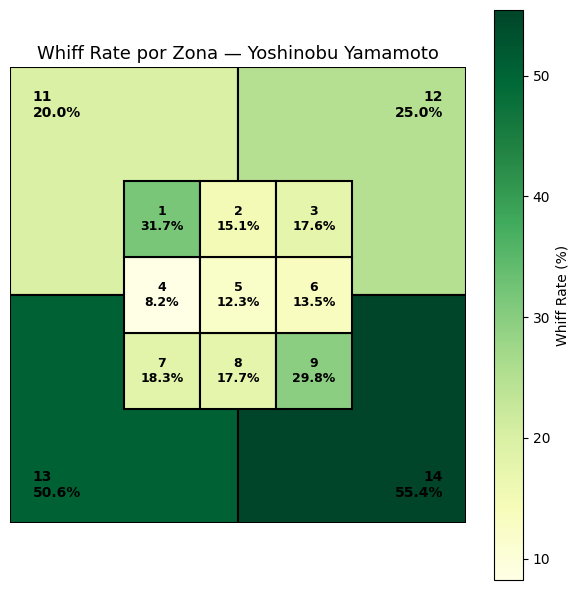

In [8]:
# WHIFF RATE POR ZONA

PITCHER = "Yoshinobu Yamamoto"
PITCHES = []

pitcher_df = df[df['player_name_eng'] == PITCHER].copy()

if PITCHES:
    pitcher_df = pitcher_df[pitcher_df['pitch_name'].isin(PITCHES)]

# whiff = swing and miss
# swings = qualquer swing (hit, foul, miss)
pitcher_df['is_whiff'] = pitcher_df['description'].isin(['swinging_strike', 'swinging_strike_blocked'])
pitcher_df['is_swing'] = pitcher_df['description'].isin([
    'swinging_strike', 'swinging_strike_blocked',
    'foul', 'foul_tip', 'hit_into_play'
])

# whiff rate por zona
def whiff_rate(group):
    swings = group['is_swing'].sum()
    return group['is_whiff'].sum() / swings * 100 if swings > 0 else 0

zone_whiff = pitcher_df.groupby('zone').apply(whiff_rate).to_dict()
zone_total = pitcher_df['zone'].value_counts().to_dict()

all_values = [v for v in zone_whiff.values() if v > 0]
vmin, vmax = min(all_values), max(all_values)
cmap = plt.cm.YlGn

def get_color(zone):
    val = zone_whiff.get(zone, 0)
    if val == 0:
        return (0.95, 0.95, 0.95)
    return cmap((val - vmin) / (vmax - vmin))

fig, ax = plt.subplots(figsize=(6, 6))

outer = {'x': 0, 'y': 0, 'size': 3}
inner = {'x': 0.75, 'y': 0.75, 'size': 1.5}
cell = inner['size'] / 3
mid_y = outer['size'] / 2

ext_zones = [
    (11, 0,                mid_y, outer['size']/2, outer['size'] - mid_y),
    (12, outer['size']/2,  mid_y, outer['size']/2, outer['size'] - mid_y),
    (13, 0,                0,     outer['size']/2, mid_y),
    (14, outer['size']/2,  0,     outer['size']/2, mid_y),
]

text_positions = {
    11: (0.15, 2.85, 'left',  'top'),
    12: (2.85, 2.85, 'right', 'top'),
    13: (0.15, 0.15, 'left',  'bottom'),
    14: (2.85, 0.15, 'right', 'bottom'),
}

for zone, x, y, w, h in ext_zones:
    color = get_color(zone)
    ax.add_patch(plt.Rectangle((x, y), w, h, color=color, ec='black', lw=1.5))
    tx, ty, ha, va = text_positions[zone]
    whiff = zone_whiff.get(zone, 0)
    ax.text(tx, ty, f'{zone}\n{whiff:.1f}%',
            ha=ha, va=va, fontsize=10, fontweight='bold', color='black')

inner_zones = [[7,8,9],[4,5,6],[1,2,3]]

for row_idx, row in enumerate(inner_zones):
    for col_idx, zone in enumerate(row):
        x = inner['x'] + col_idx * cell
        y = inner['y'] + row_idx * cell
        color = get_color(zone)
        whiff = zone_whiff.get(zone, 0)
        ax.add_patch(plt.Rectangle((x, y), cell, cell, color=color, ec='black', lw=1.5))
        ax.text(x + cell/2, y + cell/2, f'{zone}\n{whiff:.1f}%',
                ha='center', va='center', fontsize=9, fontweight='bold', color='black')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Whiff Rate (%)')

ax.set_xlim(0, 3)
ax.set_ylim(0, 3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'Whiff Rate por Zona — {PITCHER}', fontsize=13)
plt.tight_layout()
plt.show()